In [1]:
# Импорт необходимых библиотек
import pandas as pd

# Чтение данных из CSV файла
df = pd.read_csv('data/AirPass.csv')

# Удаление первого столбца (порядковый номер строки), если он считался как признак
if df.columns[0] == 'Unnamed: 0' or df.columns[0] == 'id':
    df = df.drop(df.columns[0], axis=1)

# Подсчет общего количества пропущенных значений
missing_values = df.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_values}")

# Вывод количества пропущенных значений по каждому столбцу
print("\nПропущенные значения по столбцам:")
print(df.isnull().sum())

Общее количество пропущенных значений: 310

Пропущенные значения по столбцам:
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Min

In [2]:
# Заполнение пропущенных значений медианными значениями для числовых столбцов
df = df.fillna(df.median(numeric_only=True))

# Вычисление среднего арифметического для столбца 'Arrival Delay in Minutes'
mean_arrival_delay = df['Arrival Delay in Minutes'].mean()

# Вывод результата, округленного до двух знаков
print(f"Среднее арифметическое для задержки при прибытии: {mean_arrival_delay:.2f}")

Среднее арифметическое для задержки при прибытии: 15.13


1. Удовлетворенность по полу:
satisfaction  satisfied  neutral or dissatisfied  Satisfied (%)  \
Gender                                                            
Female            22534                    30193          42.74   
Male              22491                    28686          43.95   

satisfaction  Neutral/Dissatisfied (%)  
Gender                                  
Female                           57.26  
Male                             56.05  


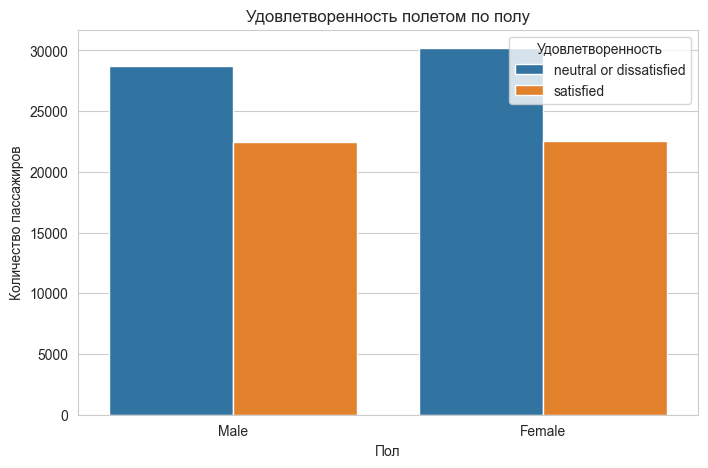


2. Удовлетворенность по цели поездки:
satisfaction     satisfied  neutral or dissatisfied  Satisfied (%)  \
Type of Travel                                                       
Business travel      41746                    29909          58.26   
Personal Travel       3279                    28970          10.17   

satisfaction     Neutral/Dissatisfied (%)  
Type of Travel                             
Business travel                     41.74  
Personal Travel                     89.83  


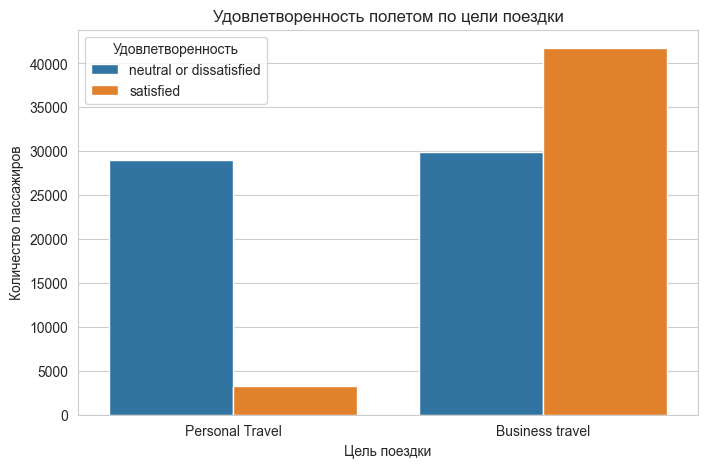


3. Удовлетворенность по туристическому классу:
satisfaction  satisfied  neutral or dissatisfied  Satisfied (%)  \
Class                                                             
Business          34480                    15185          69.43   
Eco                8701                    38044          18.61   
Eco Plus           1844                     5650          24.61   

satisfaction  Neutral/Dissatisfied (%)  
Class                                   
Business                         30.57  
Eco                              81.39  
Eco Plus                         75.39  


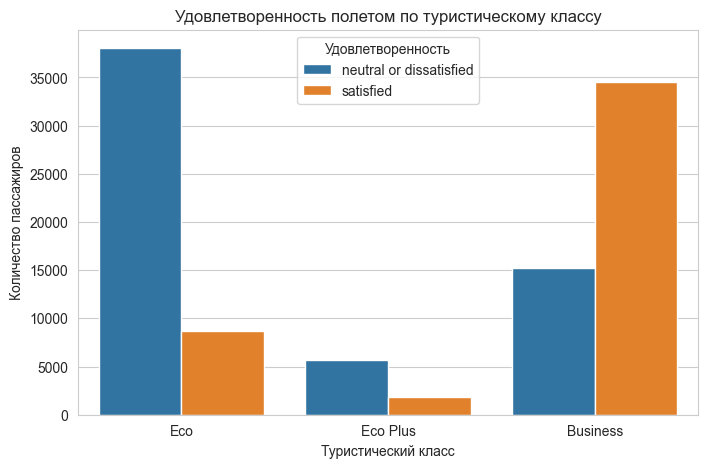

In [3]:
# Импорт библиотек для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля визуализаций
sns.set_style("whitegrid")

# 1. Анализ удовлетворенности по полу
print("1. Удовлетворенность по полу:")
gender_satisfaction = df.groupby(['Gender', 'satisfaction']).size().unstack(fill_value=0)
gender_satisfaction['Total'] = gender_satisfaction.sum(axis=1)
gender_satisfaction['Satisfied (%)'] = (gender_satisfaction['satisfied'] / gender_satisfaction['Total'] * 100).round(2)
gender_satisfaction['Neutral/Dissatisfied (%)'] = (gender_satisfaction['neutral or dissatisfied'] / gender_satisfaction['Total'] * 100).round(2)
print(gender_satisfaction[['satisfied', 'neutral or dissatisfied', 'Satisfied (%)', 'Neutral/Dissatisfied (%)']])

# Визуализация
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='satisfaction')
plt.title('Удовлетворенность полетом по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пассажиров')
plt.legend(title='Удовлетворенность')
plt.show()

# 2. Анализ удовлетворенности по цели поездки
print("\n2. Удовлетворенность по цели поездки:")
travel_type_satisfaction = df.groupby(['Type of Travel', 'satisfaction']).size().unstack(fill_value=0)
travel_type_satisfaction['Total'] = travel_type_satisfaction.sum(axis=1)
travel_type_satisfaction['Satisfied (%)'] = (travel_type_satisfaction['satisfied'] / travel_type_satisfaction['Total'] * 100).round(2)
travel_type_satisfaction['Neutral/Dissatisfied (%)'] = (travel_type_satisfaction['neutral or dissatisfied'] / travel_type_satisfaction['Total'] * 100).round(2)
print(travel_type_satisfaction[['satisfied', 'neutral or dissatisfied', 'Satisfied (%)', 'Neutral/Dissatisfied (%)']])

# Визуализация
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type of Travel', hue='satisfaction')
plt.title('Удовлетворенность полетом по цели поездки')
plt.xlabel('Цель поездки')
plt.ylabel('Количество пассажиров')
plt.legend(title='Удовлетворенность')
plt.show()

# 3. Анализ удовлетворенности по туристическому классу
print("\n3. Удовлетворенность по туристическому классу:")
class_satisfaction = df.groupby(['Class', 'satisfaction']).size().unstack(fill_value=0)
class_satisfaction['Total'] = class_satisfaction.sum(axis=1)
class_satisfaction['Satisfied (%)'] = (class_satisfaction['satisfied'] / class_satisfaction['Total'] * 100).round(2)
class_satisfaction['Neutral/Dissatisfied (%)'] = (class_satisfaction['neutral or dissatisfied'] / class_satisfaction['Total'] * 100).round(2)
print(class_satisfaction[['satisfied', 'neutral or dissatisfied', 'Satisfied (%)', 'Neutral/Dissatisfied (%)']])

# Визуализация
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class', hue='satisfaction', order=['Eco', 'Eco Plus', 'Business'])
plt.title('Удовлетворенность полетом по туристическому классу')
plt.xlabel('Туристический класс')
plt.ylabel('Количество пассажиров')
plt.legend(title='Удовлетворенность')
plt.show()

In [4]:
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied':0 , 'satisfied':1})
df['Customer Type'] = df['Customer Type'].map({'Loyal Customer':1, 'disloyal Customer':0})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel':0, 'Business travel':1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [5]:
# Создание dummy-переменных для категориального признака 'Class'
df = pd.get_dummies(df, columns=['Class'], drop_first=False)

# Подсчет общего количества признаков (включая целевую переменную 'satisfaction')
num_features = df.shape[1]
print(f"Количество признаков в данных (включая целевую переменную): {num_features}")

Количество признаков в данных (включая целевую переменную): 26


In [6]:
# Импорт функции для разделения данных
from sklearn.model_selection import train_test_split

# Разделение данных на признаки (X) и целевую переменную (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Разбиение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)

# Подсчет количества наблюдений в тестовой выборке
num_test_observations = X_test.shape[0]
print(f"Количество наблюдений в тестовой выборке: {num_test_observations}")

Количество наблюдений в тестовой выборке: 20781


In [7]:
# Импорт StandardScaler
from sklearn.preprocessing import StandardScaler

# Инициализация StandardScaler
scaler = StandardScaler()

# Обучение scaler на обучающей выборке и преобразование признаков
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Получение первого значения из матрицы преобразованных признаков тестовой выборки
first_value = X_test_scaled[0, 0]

# Вывод значения, округленного до двух знаков после точки
print(f"Первое значение из матрицы преобразованных признаков тестовой выборки: {first_value:.2f}")

Первое значение из матрицы преобразованных признаков тестовой выборки: 0.94


In [8]:
# Импорт логистической регрессии и метрики f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Инициализация и обучение логистической регрессии
logreg = LogisticRegression(random_state=26)
logreg.fit(X_train_scaled, y_train)

# Предсказание на тестовой выборке
y_pred = logreg.predict(X_test_scaled)

# Вычисление f1_score на тестовой выборке
f1 = f1_score(y_test, y_pred)

# Вывод результата, округленного до трех знаков после точки
print(f"f1_score на тестовой выборке: {f1:.3f}")

f1_score на тестовой выборке: 0.855


In [9]:
# Импорт AdaBoost и DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Инициализация базовой модели — решающее дерево
base_estimator = DecisionTreeClassifier(random_state=26)

# Инициализация и обучение AdaBoost
adaboost = AdaBoostClassifier(base_estimator=base_estimator, learning_rate=0.01, random_state=26)
adaboost.fit(X_train_scaled, y_train)

# Предсказание на тестовой выборке
y_pred_adaboost = adaboost.predict(X_test_scaled)

# Вычисление f1_score на тестовой выборке
f1_adaboost = f1_score(y_test, y_pred_adaboost)

# Вывод результата, округленного до трех знаков
print(f"f1_score для AdaBoost на тестовой выборке: {f1_adaboost:.3f}")

C:\Users\mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


f1_score для AdaBoost на тестовой выборке: 0.940


In [10]:
# Импорт GradientBoostingClassifier и GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import numpy as np

# Определение сетки параметров
params = {
    "n_estimators": 2 ** np.arange(8),  # [1, 2, 4, 8, 16, 32, 64, 128]
    "learning_rate": 0.1 ** np.arange(3)  # [1.0, 0.1, 0.01]
}

# Инициализация GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=26)

# Инициализация GridSearchCV
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=params,
    scoring='f1',
    cv=3,
    n_jobs=-1  # Используем все доступные ядра для ускорения
)

# Обучение GridSearchCV на тренировочных данных
grid_search.fit(X_train_scaled, y_train)

# Получение лучшего значения f1_score на тренировочных данных (из кросс-валидации)
best_f1_score = grid_search.best_score_

# Вывод лучшего результата, округленного до трех знаков
print(f"Наибольшее значение f1_score на тренировочных данных: {best_f1_score:.3f}")

# Вывод лучших параметров для информации
print(f"Лучшие параметры: {grid_search.best_params_}")

Наибольшее значение f1_score на тренировочных данных: 0.949
Лучшие параметры: {'learning_rate': 1.0, 'n_estimators': 128}


In [11]:
# Импорт XGBClassifier и f1_score
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# Инициализация и обучение XGBClassifier
xgb = XGBClassifier(random_state=26, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

# Предсказание на тестовой выборке
y_pred_xgb = xgb.predict(X_test_scaled)

# Вычисление f1_score на тестовой выборке
f1_xgb = f1_score(y_test, y_pred_xgb)

# Вывод результата, округленного до трех знаков
print(f"f1_score для XGBoost на тестовой выборке: {f1_xgb:.3f}")

f1_score для XGBoost на тестовой выборке: 0.957


In [12]:
# Импорт CatBoostClassifier и f1_score
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score

# Инициализация и обучение CatBoostClassifier
catboost = CatBoostClassifier(random_state=26, verbose=0)
catboost.fit(X_train_scaled, y_train)

# Предсказание на тестовой выборке
y_pred_catboost = catboost.predict(X_test_scaled)

# Вычисление f1_score на тестовой выборке
f1_catboost = f1_score(y_test, y_pred_catboost)

# Вывод результата, округленного до трех знаков
print(f"f1_score для CatBoost на тестовой выборке: {f1_catboost:.3f}")

f1_score для CatBoost на тестовой выборке: 0.960


In [14]:
# Импорт необходимых функций и классов
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# Инициализация и обучение CatBoostClassifier
catboost = CatBoostClassifier(random_state=26, verbose=0)
catboost.fit(X_train_scaled, y_train)

# Предсказание на обучающей выборке
y_pred_train = catboost.predict(X_train_scaled)

# Получение матрицы ошибок с помощью sklearn
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Общее количество наблюдений в обучающей выборке
total_observations = X_train_scaled.shape[0]

# Перевод значений матрицы ошибок в проценты
conf_matrix_percent = (conf_matrix / total_observations * 100).round(0).astype(int)

# Извлечение значений TN, FP, FN, TP
TN = conf_matrix_percent[0, 0]  # True Negative
FP = conf_matrix_percent[0, 1]  # False Positive
FN = conf_matrix_percent[1, 0]  # False Negative
TP = conf_matrix_percent[1, 1]  # True Positive

# Вывод матрицы ошибок в процентах
print("Матрица ошибок в процентах от общего числа наблюдений в обучающей выборке:")
print(f"TN: {TN}%")
print(f"FP: {FP}%")
print(f"FN: {FN}%")
print(f"TP: {TP}%")

# Вычисление f1_score на обучающей выборке для проверки
f1_train = f1_score(y_train, y_pred_train)
print(f"f1_score для CatBoost на обучающей выборке: {f1_train:.3f}")

Матрица ошибок в процентах от общего числа наблюдений в обучающей выборке:
TN: 56%
FP: 1%
FN: 2%
TP: 42%
f1_score для CatBoost на обучающей выборке: 0.975


In [16]:
# Импорт pandas для работы с DataFrame
import pandas as pd

# Получение важности признаков из модели CatBoost
feature_importances = catboost.get_feature_importance()
feature_names = X_train.columns  # Используем имена столбцов из X_train (до масштабирования)

# Создание DataFrame для удобного отображения важности признаков
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Сортировка по убыванию важности
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Вывод всех признаков с их важностью
print("Важность признаков для модели CatBoost:")
print(importance_df)

# Нахождение признака с наибольшей важностью из предложенного списка
relevant_features = [
    'Gender', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service',
    'Ease of Online booking', 'Online boarding', 'On-board service', 'Departure Delay in Minutes'
]
# Учитываем, что 'Class' был преобразован в dummy-переменные (Class_Eco, Class_Eco Plus, Class_Business)
# Суммируем важность для всех dummy-переменных Class
class_features = [f for f in feature_names if f.startswith('Class_')]
class_importance = importance_df[importance_df['Feature'].isin(class_features)]['Importance'].sum()
other_importances = importance_df[importance_df['Feature'].isin(relevant_features)][['Feature', 'Importance']]

# Создаем DataFrame с общей важностью для 'Class' и другими признаками
combined_importance = pd.DataFrame([
    {'Feature': 'Class', 'Importance': class_importance}
] + other_importances.to_dict('records'))

# Сортировка и нахождение признака с максимальной важностью
max_feature = combined_importance.loc[combined_importance['Importance'].idxmax()]

# Вывод признака с наибольшей важностью
print(f"\nПризнак с наибольшей важностью: {max_feature['Feature']} (Важность: {max_feature['Importance']:.2f})")

Важность признаков для модели CatBoost:
                              Feature  Importance
6               Inflight wifi service   25.329103
4                      Type of Travel   18.161031
11                    Online boarding    7.429019
2                       Customer Type    7.293092
22                     Class_Business    5.514859
17                    Checkin service    3.938168
3                                 Age    3.797618
16                   Baggage handling    3.698958
9                       Gate location    3.256603
18                   Inflight service    2.935592
12                       Seat comfort    2.923553
13             Inflight entertainment    2.805014
0                                  id    2.011917
5                     Flight Distance    1.688502
7   Departure/Arrival time convenient    1.549199
19                        Cleanliness    1.525832
8              Ease of Online booking    1.496001
14                   On-board service    1.381004
15        